In [2]:
import numpy as np
X = [10.2,12.5,9.8,11.0,13.2]
Y = [5.1,6.3,4.9,5.5,6.8]
X = np.array(X)
Y = np.array(Y)


mean_x = sum(X)/len(X)
var_x = sum((x - mean_x)**2 for x in X) / len(X)


mean_y = sum(Y)/len(Y)

cov_xy = 0
for i in range(len(X)):
    cov_xy += (X[i] - mean_x)*(Y[i]-mean_y) 

a = cov_xy / var_x
b = mean_y - a*mean_x

x = 15.0
y_hat = a *x + b
y_hat

np.float64(15.785851955307258)

初始化 a, b
重复以下步骤直到收敛：
    1. 用当前 a, b 计算所有预测值 ŷ
    2. 计算误差 J(a, b)
    3. 计算梯度 ∂J/∂a 和 ∂J/∂b
    4. 更新 a 和 b
最终得到最优的 a 和 b


In [4]:
# 原始数据
X = [10.2, 12.5, 9.8, 11.0, 13.2]
Y = [5.1, 6.3, 4.9, 5.5, 6.8]

# 初始化参数
a = 0.0  # 斜率
b = 0.0  # 截距
lr = 0.001  # 学习率
epochs = 1000  # 迭代次数
n = len(X)

# 梯度下降迭代
for epoch in range(epochs):
    # 计算预测值和误差
    y_pred = []
    for i in range(n):
        y_hat = a * X[i] + b
        y_pred.append(y_hat)

    # 计算误差项
    error = []
    for i in range(n):
        error.append(y_pred[i] - Y[i])

    # 计算梯度 da 和 db
    da = 0
    db = 0
    for i in range(n):
        da += error[i] * X[i]
        db += error[i]
    da = (2 / n) * da
    db = (2 / n) * db

    # 更新参数
    a -= lr * da
    b -= lr * db

    # 每100轮打印一次成本函数
    if epoch % 100 == 0:
        cost = 0
        for i in range(n):
            cost += (y_pred[i] - Y[i]) ** 2
        cost /= n
        print(f"Epoch {epoch}: Cost={cost:.4f}, a={a:.4f}, b={b:.4f}")

# 指定一个特定的 x 值进行预测
x = 12.5
y_hat = a * x + b
print(f"\n当 x = {x} 时，预测值 ŷ = {y_hat:.4f}")


Epoch 0: Cost=33.2400, a=0.1316, b=0.0114
Epoch 100: Cost=0.0058, a=0.5013, b=0.0421
Epoch 200: Cost=0.0058, a=0.5015, b=0.0407
Epoch 300: Cost=0.0058, a=0.5016, b=0.0392
Epoch 400: Cost=0.0058, a=0.5017, b=0.0378
Epoch 500: Cost=0.0057, a=0.5018, b=0.0363
Epoch 600: Cost=0.0057, a=0.5020, b=0.0349
Epoch 700: Cost=0.0057, a=0.5021, b=0.0334
Epoch 800: Cost=0.0057, a=0.5022, b=0.0320
Epoch 900: Cost=0.0057, a=0.5023, b=0.0305

当 x = 12.5 时，预测值 ŷ = 6.3100


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 模拟基因表达量（X）和蛋白质丰度（Y）
np.random.seed(42)
X = np.random.uniform(5, 15, size=50)  # mRNA表达量
true_a, true_b = 2.5, 10
noise = np.random.normal(0, 3, size=50)
Y = true_a * X + true_b + noise  # 蛋白质丰度


In [6]:
print("X:", X)
print("Y:", Y)


X: [ 8.74540119 14.50714306 12.31993942 10.98658484  6.5601864   6.5599452
  5.58083612 13.66176146 11.01115012 12.08072578  5.20584494 14.69909852
 13.32442641  7.12339111  6.81824967  6.8340451   8.04242243 10.24756432
  9.31945019  7.9122914  11.11852895  6.39493861  7.92144649  8.66361843
  9.56069984 12.85175961  6.99673782 10.14234438 10.92414569  5.46450413
 11.07544852  6.70524124  5.65051593 14.48885537 14.65632033 13.08397348
  8.04613769  5.97672114 11.84233027  9.40152494  6.22038235  9.9517691
  5.34388521 14.09320402  7.58779982 11.62522284  8.11711076 10.20068021
 10.46710279  6.84854456]
Y: [34.07890271 46.7819625  40.4529037  36.56315102 21.96490004 24.24033038
 22.57017399 47.32577032 38.55873016 34.91269398 23.98686427 45.59249946
 41.28030002 29.64350663 30.13862275 29.8789531  27.5884035  34.69127366
 34.29241576 32.70736389 36.35879965 25.43036959 26.48461129 28.07042621
 36.33932707 46.19811912 27.27581419 38.36645965 38.3952723  21.72590105
 38.77280811 31.37721

Epoch 0: Cost=1187.4186, a=0.6762, b=0.0673
Epoch 200: Cost=15.7100, a=3.3981, b=0.6703
Epoch 400: Cost=15.1767, a=3.3666, b=0.9952
Epoch 600: Cost=14.6778, a=3.3361, b=1.3096
Epoch 800: Cost=14.2108, a=3.3066, b=1.6137
Epoch 1000: Cost=13.7739, a=3.2781, b=1.9079
Epoch 1200: Cost=13.3650, a=3.2505, b=2.1925
Epoch 1400: Cost=12.9824, a=3.2238, b=2.4678
Epoch 1600: Cost=12.6244, a=3.1980, b=2.7341
Epoch 1800: Cost=12.2893, a=3.1730, b=2.9917


c:\Users\Windows\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34507 (\N{CJK UNIFIED IDEOGRAPH-86CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Windows\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30333 (\N{CJK UNIFIED IDEOGRAPH-767D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Windows\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36136 (\N{CJK UNIFIED IDEOGRAPH-8D28}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Windows\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20016 (\N{CJK UNIFIED IDEOGRAPH-4E30}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Windows\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from fon

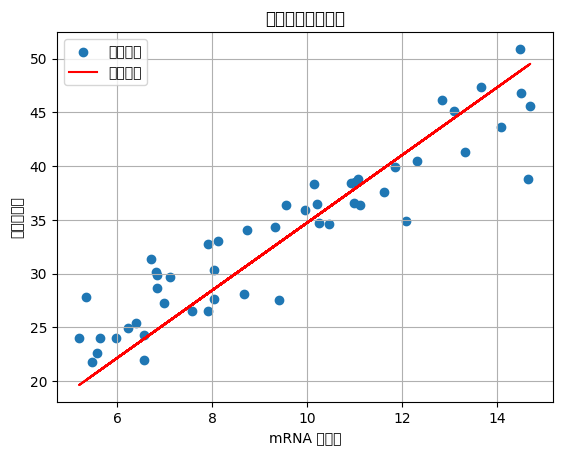

In [7]:
a = 0.0
b = 0.0
lr = 0.001
epochs = 2000
n = len(X)
for epoch in range(epochs):
    y_pred = a * X + b
    error = y_pred - Y

    da = (2 / n) * np.dot(error, X)
    db = (2 / n) * np.sum(error)

    a -= lr * da
    b -= lr * db

    if epoch % 200 == 0:
        cost = np.mean(error ** 2)
        print(f"Epoch {epoch}: Cost={cost:.4f}, a={a:.4f}, b={b:.4f}")

plt.scatter(X, Y, label='真实数据')
plt.plot(X, a * X + b, color='red', label='拟合直线')
plt.xlabel('mRNA 表达量')
plt.ylabel('蛋白质丰度')
plt.title('线性回归拟合效果')
plt.legend()
plt.grid(True)
plt.show()


梯度下降实现一元线性回归（逐行解释）
我们使用梯度下降法拟合一个线性模型：

```代码
y_hat = a * x + b
```
目标是最小化均方误差（MSE）：

```代码
MSE = (1/n) * Σ (y_i - y_hat_i)^2
```
初始化参数
```python
a = 0.0
b = 0.0
```
初始化模型参数：斜率 a 和截距 b

从零开始学习

```python
lr = 0.001
```
学习率（learning rate）：控制每次参数更新的步长

```python
epochs = 2000
```
训练轮数：模型将迭代 2000 次

```python
n = len(X)
```
样本数量 n，用于归一化梯度计算

梯度下降主循环
```python
for epoch in range(epochs):
```
训练主循环，执行多轮参数更新

前向传播（预测）
```python
    y_pred = a * X + b
```
使用当前参数计算预测值 y_hat

计算误差
```python
    error = y_pred - Y
```
误差向量：预测值减去真实值

计算梯度
```python
    da = (2 / n) * np.dot(error, X)
```
对 a 的梯度（∂MSE/∂a）

使用向量内积计算 Σ(error_i * x_i)

```python
    db = (2 / n) * np.sum(error)
```
对 b 的梯度（∂MSE/∂b）

计算误差总和

参数更新
```python
    a -= lr * da
    b -= lr * db
```
梯度下降更新公式：

a ← a - lr * da

b ← b - lr * db

每 200 轮打印一次损失和参数
```python
    if epoch % 200 == 0:
        cost = np.mean(error ** 2)
        print(f"Epoch {epoch}: Cost={cost:.4f}, a={a:.4f}, b={b:.4f}")
```
计算当前均方误差（MSE）

打印当前轮数、损失值、参数值

方便观察收敛过程

In [8]:
import numpy as np

np.random.seed(42)

# 样本数
n_samples = 100

# 模拟基因表达矩阵 (100个样本, 3个基因)
X = np.random.rand(n_samples, 3) * 10  

# 真实参数 (假设基因1和基因2影响药物反应，基因3影响较小)
true_w = np.array([1.5, -2.0, 0.5])
true_b = 5.0

# 加入噪音，模拟实验误差
noise = np.random.normal(0, 1, size=n_samples)

# 药物反应值
Y = X @ true_w + true_b + noise
print(X)

[[3.74540119 9.50714306 7.31993942]
 [5.98658484 1.5601864  1.5599452 ]
 [0.58083612 8.66176146 6.01115012]
 [7.08072578 0.20584494 9.69909852]
 [8.32442641 2.12339111 1.81824967]
 [1.8340451  3.04242243 5.24756432]
 [4.31945019 2.9122914  6.11852895]
 [1.39493861 2.92144649 3.66361843]
 [4.56069984 7.85175961 1.99673782]
 [5.14234438 5.92414569 0.46450413]
 [6.07544852 1.70524124 0.65051593]
 [9.48885537 9.65632033 8.08397348]
 [3.04613769 0.97672114 6.84233027]
 [4.40152494 1.22038235 4.9517691 ]
 [0.34388521 9.09320402 2.58779982]
 [6.62522284 3.11711076 5.20068021]
 [5.46710279 1.84854456 9.69584628]
 [7.75132823 9.39498942 8.9482735 ]
 [5.97899979 9.21874235 0.88492502]
 [1.95982862 0.45227289 3.25330331]
 [3.8867729  2.71349032 8.28737509]
 [3.56753327 2.8093451  5.42696083]
 [1.40924225 8.02196981 0.74550644]
 [9.86886937 7.72244769 1.98715682]
 [0.05522117 8.15461428 7.06857344]
 [7.29007168 7.71270347 0.74044652]
 [3.58465729 1.1586906  8.63103426]
 [6.23298127 3.30898025 0.63

In [9]:
# 初始化参数
w = np.zeros(3)
b = 0.0
lr = 0.001
epochs = 5000
for epoch in range(epochs):
    # 计算预测值
    y_pred = X @ w + b
    error = y_pred - Y

    # 计算梯度
    dw = (2 / n_samples) * (X.T @ error)
    db = (2 / n_samples) * np.sum(error)

    # 更新参数
    w -= lr * dw
    b -= lr * db

    if epoch % 500 == 0:
        cost = np.mean(error ** 2)
        print(f"Epoch {epoch}: Cost={cost:.4f}, w={w}, b={b:.4f}")

Epoch 0: Cost=77.0950, w=[0.06452228 0.00853375 0.05167765], b=0.0089
Epoch 500: Cost=2.7110, w=[ 1.79108339 -1.79604683  0.84112862], b=0.5232
Epoch 1000: Cost=2.3870, w=[ 1.76644647 -1.81729827  0.81419592], b=0.9233
Epoch 1500: Cost=2.1217, w=[ 1.74378042 -1.83614941  0.7897718 ], b=1.2853
Epoch 2000: Cost=1.9043, w=[ 1.72326706 -1.85321001  0.76766744], b=1.6130
Epoch 2500: Cost=1.7263, w=[ 1.70470202 -1.86865024  0.74766251], b=1.9095
Epoch 3000: Cost=1.5805, w=[ 1.68790024 -1.88262398  0.72955761], b=2.1778
Epoch 3500: Cost=1.4610, w=[ 1.67269427 -1.89527052  0.71317227], b=2.4207
Epoch 4000: Cost=1.3632, w=[ 1.65893253 -1.90671592  0.69834319], b=2.6405
Epoch 4500: Cost=1.2831, w=[ 1.64647786 -1.91707426  0.68492254], b=2.8395


In [10]:
import pandas as pd
df = pd.read_csv('C:/Users/Windows/Downloads/Expression_Public_25Q3_subsetted.csv',index_col=0)
df

,KRAS,TP53,EGFR
ACH-000012,4.640147,5.842650,9.624209
ACH-000015,3.267786,2.608840,0.112740
ACH-000021,3.406769,4.131853,5.303799
ACH-000029,4.954434,6.877904,8.111141
ACH-000030,4.288314,6.693138,6.458651
...,...,...,...
ACH-002522,5.489893,4.030424,4.540133
ACH-002526,4.378851,5.706506,7.212219
ACH-002531,5.182196,5.939756,5.151400
ACH-002650,4.153684,2.188376,7.369728


In [11]:
import numpy as np
import pandas as pd

# 假设你的表达矩阵变量名为 df，且 index 是 ACH-xxxx
# 示例： df.shape -> (142, 3)

seed = 42
rng = np.random.default_rng(seed)
n = df.shape[0]

# 简单随机生成并缩放为 AUC(0.02-0.98) 和 IC50(10^0.5 - 10^4.5)
def to_01(x):
    x = np.asarray(x, dtype=float)
    x = (x - x.min()) / (x.max() - x.min())
    return 0.02 + 0.96 * x

v1 = rng.normal(size=n)
v2 = rng.normal(size=n)
DrugA_AUC = to_01(v1 + 0.2 * rng.normal(size=n))
DrugB_AUC = to_01(-0.5 * v1 + 0.4 * v2 + 0.1 * rng.normal(size=n))

v3 = rng.normal(size=n)
v3s = v3 - v3.min() + 1e-6
log10_vals = 0.5 + (v3s - v3s.min()) / (v3s.max() - v3s.min()) * (4.5 - 0.5)
DrugC_IC50 = 10 ** log10_vals

drug_df = pd.DataFrame({
    'DrugA_AUC': DrugA_AUC,
    'DrugB_AUC': DrugB_AUC,
    'DrugC_IC50': DrugC_IC50
}, index=df.index)

# 查看结果
print(drug_df.shape)
print(drug_df.head())


(142, 3)
            DrugA_AUC  DrugB_AUC  DrugC_IC50
ACH-000012   0.454043   0.322141  860.963908
ACH-000015   0.201572   0.772729  449.835360
ACH-000021   0.603537   0.344670   23.624806
ACH-000029   0.634214   0.407784  283.699044
ACH-000030   0.020000   0.727636  514.022075


In [12]:
# 1. 合并并选择要拟合的药物列（例如 DrugA_AUC 或 log10(DrugC_IC50)）
merged = df.join(drug_df, how='inner')
print('merged shape', merged.shape)

merged shape (142, 6)


In [13]:
# 2. 选择特征和标签
X = merged[['KRAS', 'TP53', 'EGFR']].values.astype(float)
# 若用 DrugC_IC50，推荐取对数；若用 AUC 可直接作为 y
y = np.log10(merged['DrugC_IC50'].values.astype(float))  # 或: merged['DrugA_AUC'].values.astype(float)

In [14]:
# merged 是你已有的 DataFrame（index 为 ACH-xxxx，包含 KRAS,TP53,EGFR 和 DrugA_AUC）
# 1) 抽取特征矩阵 X 和标签 y（本质：把表格转换为 numpy 数组）
X = merged[['KRAS','TP53','EGFR']].values   # 形状 (N,3)
y = merged['DrugA_AUC'].values              # 形状 (N,)

# 2) 可直接用原始表达值，也可标准化（推荐）
mu = X.mean(axis=0); sigma = X.std(axis=0); sigma[sigma==0]=1.0
X = (X - mu) / sigma    # 若不想标准化就跳过这行

# 3) 加 bias 列（把截距 a 包含进权重向量）
X_aug = np.hstack([np.ones((X.shape[0],1)), X])  # 形状 (N,4)

# 4) 初始化参数，做批量梯度下降（从 0 开始）
w = np.zeros(X_aug.shape[1])   # [bias, w1, w2, w3]
lr = 0.01
for _ in range(5000):
    grad = (2.0 / X_aug.shape[0]) * (X_aug.T.dot(X_aug.dot(w) - y))
    w -= lr * grad

# 5) 结果：w[0] 是截距，w[1:] 是每个基因对应的系数
print('weights:', w)


weights: [ 0.42957258  0.02643397 -0.00818944 -0.00667993]


In [15]:
import numpy as np

# 假设 merged 已有，包含 KRAS, TP53, EGFR, 和目标 DrugA_AUC
# 取出特征矩阵和标签（不强制标准化，按你要的直接用表达值也可以）
X_raw = merged[['KRAS', 'TP53', 'EGFR']].values.astype(float)  # shape (N,3)
y = merged['DrugA_AUC'].values.astype(float)                   # shape (N,)

# 可选：为了稳定训练建议标准化特征（但你可以跳过）
mu = X_raw.mean(axis=0)
sigma = X_raw.std(axis=0, ddof=0)
sigma[sigma == 0] = 1.0
X = (X_raw - mu) / sigma   # 若不想标准化，用 X = X_raw

# 把 bias 列（全 1）拼到前面
N = X.shape[0]
X_aug = np.hstack([np.ones((N, 1)), X])  # shape (N, 4)

# 初始化参数全部为 0
w = np.zeros(X_aug.shape[1])  # [a, b1, b2, b3]

# 超参数
lr = 0.01      # 学习率
epochs = 2000  # 迭代次数（视情况增减）

# 梯度下降：每次用全部样本（批量梯度下降）
for it in range(epochs):
    y_hat = X_aug.dot(w)          # 预测
    e = y_hat - y                 # 误差 = y_hat - y
    mse = np.mean(e**2)           # 当前 MSE（可以打印观察）
    grad = (2.0 / N) * (X_aug.T.dot(e))  # ∇w MSE
    w -= lr * grad                # 更新参数

    # 可选每 200 次打印一次 MSE
    if (it + 1) % 200 == 0:
        print(f'iter {it+1:4d}  MSE={mse:.6f}')

# 训练结束，输出结果
print('Final parameters (a, b1, b2, b3):', w)
# 若用了标准化，解释：b_i 表示该基因标准差增加 1 单位时 y 的变化量


iter  200  MSE=0.031703
iter  400  MSE=0.031643
iter  600  MSE=0.031643
iter  800  MSE=0.031643
iter 1000  MSE=0.031643
iter 1200  MSE=0.031643
iter 1400  MSE=0.031643
iter 1600  MSE=0.031643
iter 1800  MSE=0.031643
iter 2000  MSE=0.031643
Final parameters (a, b1, b2, b3): [ 0.42957258  0.02643397 -0.00818944 -0.00667993]


In [16]:
import numpy as np

# 假设 X 是 (N,3)，y 是 (N,)
# 你可以选择是否标准化 X；这里假设 X 已经准备好为 X (不一定要标准化)
N = X.shape[0]

# 初始化参数
a = 0.0
b1 = 0.0
b2 = 0.0
b3 = 0.0

lr = 0.01
epochs = 2000

for it in range(epochs):
    # 1) 计算预测 y_hat（逐元素）
    y_hat = a + b1 * X[:,0] + b2 * X[:,1] + b3 * X[:,2]   # shape (N,)

    # 2) 计算误差向量 e = y_hat - y
    e = y_hat - y                                           # shape (N,)

    # 3) 逐分量计算偏导
    grad_a = (2.0 / N) * np.sum(e)                          # ∂L/∂a
    grad_b1 = (2.0 / N) * np.sum(e * X[:,0])                # ∂L/∂b1
    grad_b2 = (2.0 / N) * np.sum(e * X[:,1])                # ∂L/∂b2
    grad_b3 = (2.0 / N) * np.sum(e * X[:,2])                # ∂L/∂b3

    # 4) 用学习率单独更新每个参数
    a -= lr * grad_a
    b1 -= lr * grad_b1
    b2 -= lr * grad_b2
    b3 -= lr * grad_b3

    # 可选：每 200 次打印一次损失和参数
    if (it + 1) % 200 == 0:
        mse = np.mean(e**2)
        print(f"iter {it+1:4d}  MSE={mse:.6f}  a={a:.4f} b1={b1:.4f} b2={b2:.4f} b3={b3:.4f}")


iter  200  MSE=0.031703  a=0.4220 b1=0.0258 b2=-0.0080 b3=-0.0072
iter  400  MSE=0.031643  a=0.4294 b1=0.0264 b2=-0.0082 b3=-0.0067
iter  600  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067
iter  800  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067
iter 1000  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067
iter 1200  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067
iter 1400  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067
iter 1600  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067
iter 1800  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067
iter 2000  MSE=0.031643  a=0.4296 b1=0.0264 b2=-0.0082 b3=-0.0067


In [17]:
# 1. 构造 DataFrame（用你给的原始表格）
data = {
    "Genotype": ["AA", "AG", "GG", "AG", "AA"],
    "Tissue":   ["Liver", "Kidney", "Heart", "Brain", "Liver"],
    "Age":      [45, 50, 60, 40, 55],
    "Expression": [5.2, 6.1, 7.3, 4.8, 6.5]
}
df = pd.DataFrame(data)
print("原始数据：")
print(df, "\n")

原始数据：
  Genotype  Tissue  Age  Expression
0       AA   Liver   45         5.2
1       AG  Kidney   50         6.1
2       GG   Heart   60         7.3
3       AG   Brain   40         4.8
4       AA   Liver   55         6.5 



In [18]:
# 2. One-Hot 编码（对 Genotype 和 Tissue）
df_encoded = pd.get_dummies(df, columns=["Genotype", "Tissue"], drop_first=False)
# drop_first=False 保留所有类别（也可以 drop_first=True 以去掉虚拟变量陷阱）
print("One-Hot 编码后：")
print(df_encoded, "\n")

One-Hot 编码后：
   Age  Expression  Genotype_AA  Genotype_AG  Genotype_GG  Tissue_Brain  \
0   45         5.2         True        False        False         False   
1   50         6.1        False         True        False         False   
2   60         7.3        False        False         True         False   
3   40         4.8        False         True        False          True   
4   55         6.5         True        False        False         False   

   Tissue_Heart  Tissue_Kidney  Tissue_Liver  
0         False          False          True  
1         False           True         False  
2          True          False         False  
3         False          False         False  
4         False          False          True   



In [19]:
# 3. 构建 X 和 y
#  - X 包含：截距列 + Age + 所有 one-hot 列（按 df_encoded 列顺序）
y = df_encoded["Expression"].values.reshape(-1, 1)

# 选取特征列（去掉 Label）
feature_cols = [c for c in df_encoded.columns if c != "Expression"]
X = df_encoded[feature_cols].values.astype(float)

# 在 X 左侧加一列常数 1 作为截距项
X = np.hstack([np.ones((X.shape[0], 1)), X])  # 第一列为截距
feature_names = ["Intercept"] + feature_cols

print("特征列（含截距）：")
print(feature_names, "\n")
print("X 矩阵：\n", X, "\n")
print("y 向量：\n", y.flatten(), "\n")

特征列（含截距）：
['Intercept', 'Age', 'Genotype_AA', 'Genotype_AG', 'Genotype_GG', 'Tissue_Brain', 'Tissue_Heart', 'Tissue_Kidney', 'Tissue_Liver'] 

X 矩阵：
 [[ 1. 45.  1.  0.  0.  0.  0.  0.  1.]
 [ 1. 50.  0.  1.  0.  0.  0.  1.  0.]
 [ 1. 60.  0.  0.  1.  0.  1.  0.  0.]
 [ 1. 40.  0.  1.  0.  1.  0.  0.  0.]
 [ 1. 55.  1.  0.  0.  0.  0.  0.  1.]] 

y 向量：
 [5.2 6.1 7.3 4.8 6.5] 



In [28]:
# 4. 批量梯度下降实现线性回归（MSE）
def gradient_descent(X, y, lr=0.01, epochs=2000, print_every=200):
    n_samples, n_features = X.shape
    # 参数初始化（列向量）
    w = np.zeros((n_features, 1))
    losses = []
    for epoch in range(1, epochs + 1):
        # 预测
        y_hat = X.dot(w)  # (n_samples, 1)
        # 均方误差
        error = y_hat - y
        loss = (1.0 / n_samples) * np.sum(error ** 2)
        if not np.isfinite(loss):
            print("Non-finite loss at epoch", epoch)
            break
        losses.append(loss)
        # 梯度（推导结果：2/n * X^T (Xw - y)）
        grad = (2.0 / n_samples) * (X.T.dot(error))  # (n_features, 1)
        if not np.all(np.isfinite(grad)):
            print("Non-finite grad at epoch", epoch)
            print("grad:", grad.flatten())
            break

        # 参数更新
        w = w - lr * grad
        if not np.all(np.isfinite(w)):
            print("Non-finite weights at epoch", epoch)
            print("w:", w.flatten())
            break
        if epoch % print_every == 0 or epoch == 1 or epoch == epochs:
            print(f"Epoch {epoch:5d}  loss = {loss:.6f}")
    return w, losses

# 运行梯度下降
w_final, losses = gradient_descent(X, y, lr=0.0001, epochs=2000, print_every=400)

Epoch     1  loss = 36.566000
Epoch   400  loss = 0.012673
Epoch   800  loss = 0.011544
Epoch  1200  loss = 0.010528
Epoch  1600  loss = 0.009615
Epoch  2000  loss = 0.008792


In [ ]:
# 基础 for循环 版本
# 假设 X, y, feature_names 已准备好（X 第一列是截距）
import numpy as np

lr = 0.0001
epochs = 2000
print_every = 400

n_samples, n_features = X.shape
w = np.zeros((n_features, 1))   # 参数初始化（列向量），转化为(n_features, 1)的零向量组
losses = []

for epoch in range(1, epochs + 1):
    # 预测
    y_hat = X.dot(w)                        # (n_samples, 1)

    # 均方误差（MSE）
    error = y_hat - y                       # (n_samples, 1)
    loss = (1.0 / n_samples) * np.sum(error ** 2)
    if not np.isfinite(loss):
        print("Non-finite loss at epoch", epoch)
        break
    losses.append(loss)

    # 梯度（2/n * X^T (Xw - y)）
    grad = (2.0 / n_samples) * (X.T.dot(error))  # (n_features, 1) 
    
    #计算梯度的步骤就是先算误差向量 e = Xw − y，再算矩阵乘积 Xᵀ e，最后乘以标量 2/n 得到 grad = (2/n) Xᵀ e。
    
    if not np.all(np.isfinite(grad)):
        print("Non-finite grad at epoch", epoch)
        print("grad:", grad.flatten())
        break

    # 参数更新
    w = w - lr * grad
    if not np.all(np.isfinite(w)):
        print("Non-finite weights at epoch", epoch)
        print("w:", w.flatten())
        break

    # 打印进度
    if epoch % print_every == 0 or epoch == 1 or epoch == epochs:
        print(f"Epoch {epoch:5d}  loss = {loss:.6f}")

# 训练结束，w 和 losses 可用
w_final = w
print("\n训练完成。最终参数：")
for name, coef in zip(feature_names, w_final.flatten()):
    print(f"{name:15s}: {coef:.6f}")


In [29]:
# 5. 输出最终参数并解释各特征权重
print("\n训练完成。最终参数：")
for name, coef in zip(feature_names, w_final.flatten()):
    print(f"{name:15s}: {coef:.6f}")

# 6. 可选：用模型预测并与真实值比较
y_pred = X.dot(w_final).flatten()
print("\n真实 vs 预测：")
for truth, pred in zip(y.flatten(), y_pred):
    print(f"{truth:.3f}  -->  {pred:.3f}")

# 7. 如果你希望按类别查看权重（更直观）
print("\n--- 各类别权重（去掉截距和 Age）---")
for name, coef in zip(feature_names[2:], w_final.flatten()[2:]):  # 跳过 Intercept 和 Age
    print(f"{name:25s}: {coef:.6f}")


训练完成。最终参数：
Intercept      : -0.000091
Age            : 0.119829
Genotype_AA    : -0.018270
Genotype_AG    : 0.009253
Genotype_GG    : 0.008926
Tissue_Brain   : 0.000640
Tissue_Heart   : 0.008926
Tissue_Kidney  : 0.008613
Tissue_Liver   : -0.018270

真实 vs 预测：
5.200  -->  5.356
6.100  -->  6.009
7.300  -->  7.207
4.800  -->  4.803
6.500  -->  6.554

--- 各类别权重（去掉截距和 Age）---
Genotype_AA              : -0.018270
Genotype_AG              : 0.009253
Genotype_GG              : 0.008926
Tissue_Brain             : 0.000640
Tissue_Heart             : 0.008926
Tissue_Kidney            : 0.008613
Tissue_Liver             : -0.018270


In [33]:
import numpy as np
import pandas as pd

data = {
    "Genotype": ["AA", "AG", "GG", "AG", "AA"],
    "Tissue":   ["Liver", "Kidney", "Heart", "Brain", "Liver"],
    "Age":      [45, 50, 60, 40, 55],
    "Expression": [5.2, 6.1, 7.3, 4.8, 6.5]
}
df = pd.DataFrame(data)

df_encoded = pd.get_dummies(df, columns=["Genotype","Tissue"], drop_first=False)
feature_cols = [c for c in df_encoded.columns if c != "Expression"]
X = df_encoded[feature_cols].values.astype(float)
X = np.hstack([np.ones((X.shape[0],1)), X])   # 加截距
y = df_encoded["Expression"].values.reshape(-1,1)

print("feature_names:", ["Intercept"] + feature_cols)  
''' 
你在代码里做了： X = np.hstack([np.ones((X.shape[0],1)), X]) 
所以 X 的第一列对应截距，feature_names 也要在最前面加 "Intercept"： ["Intercept"] + feature_cols 
这样 zip(feature_names, w_final.flatten()) 打印时每个名字和对应系数就对齐了。
'''
print("X.shape, y.shape:", X.shape, y.shape)
print("X:\n", X)
print("y:\n", y.flatten())


feature_names: ['Intercept', 'Age', 'Genotype_AA', 'Genotype_AG', 'Genotype_GG', 'Tissue_Brain', 'Tissue_Heart', 'Tissue_Kidney', 'Tissue_Liver']
X.shape, y.shape: (5, 9) (5, 1)
X:
 [[ 1. 45.  1.  0.  0.  0.  0.  0.  1.]
 [ 1. 50.  0.  1.  0.  0.  0.  1.  0.]
 [ 1. 60.  0.  0.  1.  0.  1.  0.  0.]
 [ 1. 40.  0.  1.  0.  1.  0.  0.  0.]
 [ 1. 55.  1.  0.  0.  0.  0.  0.  1.]]
y:
 [5.2 6.1 7.3 4.8 6.5]


简化流程一句话版：先对 Genotype/Tissue 做 one‑hot（得到若干列），把除 Expression 以外的这些特征列名放到 feature_cols，中间把它们取成 float 数组作为 X，再在 X 左侧加一列 1（截距），最后把 Expression 取出并 reshape 成列向量 y。

In [31]:
df_encoded_base = pd.get_dummies(df, columns=["Genotype","Tissue"], drop_first=True)
feature_cols2 = [c for c in df_encoded_base.columns if c != "Expression"]
X2 = df_encoded_base[feature_cols2].values.astype(float)
X2 = np.hstack([np.ones((X2.shape[0],1)), X2])
y2 = df_encoded_base["Expression"].values.reshape(-1,1)

print("feature_names (drop_first=True):", ["Intercept"] + feature_cols2)
print("X2.shape:", X2.shape)
print("X2:\n", X2)


feature_names (drop_first=True): ['Intercept', 'Age', 'Genotype_AG', 'Genotype_GG', 'Tissue_Heart', 'Tissue_Kidney', 'Tissue_Liver']
X2.shape: (5, 7)
X2:
 [[ 1. 45.  0.  0.  0.  0.  1.]
 [ 1. 50.  1.  0.  0.  1.  0.]
 [ 1. 60.  0.  1.  1.  0.  0.]
 [ 1. 40.  1.  0.  0.  0.  0.]
 [ 1. 55.  0.  0.  0.  0.  1.]]


In [32]:
df_enc = pd.get_dummies(df, columns=["Genotype","Tissue"], drop_first=False)
# 标准化 Age
age_mean = df_enc["Age"].mean()
age_std  = df_enc["Age"].std(ddof=0)
df_enc["Age_scaled"] = (df_enc["Age"] - age_mean) / age_std

# 用 Age_scaled 构建 X
feature_cols3 = [c for c in df_enc.columns if c not in ("Expression","Age")]
X3 = df_enc[feature_cols3].values.astype(float)
X3 = np.hstack([np.ones((X3.shape[0],1)), X3])
y3 = df_enc["Expression"].values.reshape(-1,1)

print("feature_names (with Age_scaled):", ["Intercept"] + feature_cols3)
print("X3.shape:", X3.shape)
print("first 3 rows of X3:\n", X3[:3])


feature_names (with Age_scaled): ['Intercept', 'Genotype_AA', 'Genotype_AG', 'Genotype_GG', 'Tissue_Brain', 'Tissue_Heart', 'Tissue_Kidney', 'Tissue_Liver', 'Age_scaled']
X3.shape: (5, 9)
first 3 rows of X3:
 [[ 1.          1.          0.          0.          0.          0.
   0.          1.         -0.70710678]
 [ 1.          0.          1.          0.          0.          0.
   1.          0.          0.        ]
 [ 1.          0.          0.          1.          0.          1.
   0.          0.          1.41421356]]


In [11]:
Data = {
    'sample': ['s1','s2','s3','s4','s5'],
    'group': ['control','control','treatment','treatment','control'],
    'geneA': [2, 0.5, 1.2, 3.0, 2.5],
    'geneB': [1.5, 2.2, 0.7, 1.0, 2.5],
    'phenotype': [5, 3, 6, 9, 8]
}
import pandas as pd

df = pd.DataFrame(Data)
df_onehot = pd.get_dummies(df, columns=['group'],drop_first = False)
print(df_onehot)



  sample  geneA  geneB  phenotype  group_control  group_treatment
0     s1    2.0    1.5          5           True            False
1     s2    0.5    2.2          3           True            False
2     s3    1.2    0.7          6          False             True
3     s4    3.0    1.0          9          False             True
4     s5    2.5    2.5          8           True            False


In [ ]:
import numpy as np

# 1. 拆分 X 和 y
# y 就是 phenotype 列。

# X 包含数值特征和 one-hot 特征（通常还会加一个截距项 1）。
# 目标向量

y = df_onehot['phenotype'].values.astype(float).reshape(-1,1)

# 特征矩阵（这里包含 geneA, geneB, group_control, group_treatment）
X = df_onehot[['geneA','geneB','group_control','group_treatment']].values.astype(float)

X = np.hstack([np.ones((X.shape[0],1)), X])  # 在最前面加一列 1 作为截距项


# 2. 初始化参数向量 w
# 通常初始化为零或小随机数

w = np.zeros((X.shape[1],1))   # 列向量


# 3. 定义损失和梯度

# 损失函数（均方误差）：
# L(w) = (1/n) * sum_i (Xw - y)^2

# 梯度：
# grad = (2/n) * X^T (Xw - y)

# 4. 批量梯度下降
lr = 0.01
epochs = 2000

n_samples = X.shape[0]

for epoch in range(epochs):
    y_hat = X.dot(w)                  # 预测值
    error = y_hat - y                 # 误差
    grad = (2.0 / n_samples) * (X.T.dot(error))  # 计算梯度
    w -= lr * grad                    # 更新参数

    if (epoch + 1) % 400 == 0:
        loss = np.mean(error ** 2)
        print(f"Epoch {epoch+1:5d}  loss = {loss:.6f}")

Epoch   400  loss = 0.210871
Epoch   800  loss = 0.172294
Epoch  1200  loss = 0.155053
Epoch  1600  loss = 0.145414
Epoch  2000  loss = 0.139946


In [ ]:
Data = {
    'sample': ['s1','s2','s3','s4','s5','s6','s7','s8','s9','s10'],
    'group': ['Control','Control','Treatment','Treatment','Control','Knockdown','Knockdown','Treatment','Control','Knockdown'],
    'GeneA': [2.0, 0.5, 1.2, 3.0, 2.5, 1.8, 2.2, 3.5, 0.8, 2.0],
    'GeneB': [1.5, 2.2, 0.7, 1.0, 2.5, 1.2, 2.8, 0.9, 1.6, 2.0],
    'Phenotype': [5, 3, 6, 9, 8, 4, 7, 10, 2, 5]}
df = pd.DataFrame(Data)
df_onehot = pd.get_dummies(df, columns=['group'], drop_first=False)
X = df_onehot[['GeneA','GeneB','group_Control','group_Knockdown','group_Treatment']].values.astype(float)
X = np.hstack([np.ones((X.shape[0],1)), X])  # 加截距
y = df_onehot['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))   # 列向量
lr = 0.01
epochs = 3000
n_samples = X.shape[0]
for epoch in range(epochs):
    y_hat = X.dot(w)
    error = y_hat - y
    grad = (2.0 / n_samples) * (X.T.dot(error))
    w -= lr * grad
    if (epoch + 1) % 500 == 0:
        loss = np.mean(error ** 2)
        print(f"Epoch {epoch+1:5d}  loss = {loss:.6f}")
print("\n最终参数：")
feature_names = ["Intercept",'GeneA','GeneB','group_Control','group_Knockdown','group_Treatment']
for name, coef in zip(feature_names, w.flatten()):
    print(f"{name:15s}: {coef:.6f}")    
    

In [ ]:
Data = {
    'sample': ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12'],
    'Condition': ['Control','Control','TreatmentA','TreatmentA','Control',
                  'Knockdown','Knockdown','TreatmentB','TreatmentB','Control',
                  'TreatmentA','Knockdown'],
    'Tissue': ['Liver','Heart','Brain','Liver','Brain',
               'Liver','Heart','Brain','Liver','Heart',
               'Brain','Liver'],
    'GeneA': [2.0, 0.5, 1.2, 3.0, 2.5, 1.0, 2.2, 2.8, 1.5, 3.1, 2.0, 2.5],
    'GeneB': [1.5, 2.2, 0.7, 1.0, 2.5, 1.8, 0.9, 1.2, 2.0, 1.5, 1.7, 2.3],
    'Phenotype': [5, 3, 6, 9, 8, 4, 7, 10, 6, 11, 7, 9]
}
